In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os
import numpy as np
import seaborn as sns
import numpy as np
from scipy.stats import rankdata, friedmanchisquare, f

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
CLF_METRICS = ["kappa"] #, "precision", "recall", "f1-score"]
CLF_MODELS = ["RandomForestClassifier"] #, "DecisionTreeClassifier", "LogisticRegression", "SVC"]

REG_METRICS = ["r2"] # , "mse", "std"]
REG_MODELS = ["RandomForestRegressor"] #, "DecisionTreeRegressor"]

DATASETS = [file for file in os.listdir("../../datasets/synthetic/") if "csv" in file]
REG_DATASETS = ["gradual_friedman.csv"]
CLF_DATASETS = list(set(DATASETS).difference(set(REG_DATASETS)))

In [3]:
def get_concept(original_idx: pd.Series, dataset: str, concept_type="last"):
    """Read the original dataframe to recover the context

    Args:
        original_idx (pd.Series): maps the metabase indexes to the original base indexes (before windowing)
        dataset (str): dataset name to be loaded
        concept_type (str, optional): how to set the window concept, it can be:
            - "last": The last concept of the batch
            - "most_frequent": The most frequent concept of the batch
    """
    filename_concept = f'../../datasets/synthetic/{dataset}'
    df_concept = pd.read_csv(filename_concept)['concept']

    concepts = []
    for idx in original_idx:
        bounds = [int(bound) for bound in idx.split(':')]
        concept_batch = df_concept[bounds[0]:bounds[1]]
        
        if concept_type == "last":
            concepts.append(concept_batch.values[-1])
        else:
            most_frequent_concept = concept_batch.value_counts().idxmax()
            concepts.append(most_frequent_concept)
    return concepts

def load_data(dataset, model, concept_type="last"):
    filename_mtl = f'../metabases/basemodel: {model} - dataset: {dataset} - with_drift_metrics.csv'
    results = pd.read_csv(filename_mtl)
    concept = get_concept(results['original_idx'], dataset, concept_type)
    results['concept'] = concept
    return results

In [4]:
def remove_unused_cols(df: pd.DataFrame) -> pd.DataFrame:
    metrics = CLF_METRICS if "kappa" in df.columns else REG_METRICS
    cols_to_keep = [
        "concept",  # concept
        *metrics,  # target cols
        *[f"last_{col}" for col in metrics],  # baseline cols
        *[col for col in df.columns if "drift" in col],  # drift metrics cols
        *[col for col in df.columns if "predicted" in col],  # mtl cols
    ]
    return df[cols_to_keep]

def gen_drift_alerts(dataset: str, model: str, metric: str) -> pd.DataFrame:
    df = load_data(dataset, model)
    offline_df = df[df["data_type"] == "offline"]
    online_df = df[df["data_type"] == "online"]
    online_df = remove_unused_cols(online_df)

    expected_mean, expected_std = offline_df[metric].mean(), offline_df[metric].std()

    for sensitivity in [0.5, 1, 1.5, 2]:
        threshold = expected_mean - expected_std * sensitivity
        online_df[f"mtl_alert_{metric}_s={sensitivity}"] = (online_df[f"predicted_{metric}"] <= threshold).astype(int)
    online_df["target_alert"] = (online_df["concept"] > 0).astype(int)
    # online_df["real_alert"] = (online_df[metric] <= threshold).astype(int)
    return online_df

In [5]:
# Partial test code
results = {}

for dataset in DATASETS:
    try:
        metric = "kappa" if dataset in CLF_DATASETS else "r2"
        model = "RandomForestClassifier" if dataset in CLF_DATASETS else "RandomForestRegressor"
        results[dataset] = gen_drift_alerts(dataset, model, metric)
    except:
        print(dataset)

# Drift label comparison

In [6]:
def get_perf_metrics(df: pd.DataFrame, dataset: str, target_col="target_alert") -> list:
    alert_cols = [c for c in df.columns if ("_drift_" in c or "_alert" in c)]
    results = []

    for col in alert_cols:
        sensitivity = col.split("s=")[1] if "s=" in col else None
        alert_type = "drift_metrics" if "_drift_" in col else col.split("_")[0]

        # Generate confusion matrix
        cm = confusion_matrix(df[target_col], df[col], labels = [0, 1]).ravel()
        results.append({
            'dataset': dataset.replace('.csv', ''),
            'alert_col': col,
            'type': alert_type,
            'sensitivity': sensitivity,
            'True Negatives': cm[0], 
            'False Positives': cm[1], 
            'False Negatives': cm[2], 
            'True Positives': cm[3],
            'accuracy': accuracy_score(df[target_col], df[col]),
            **classification_report(df[target_col], df[col], labels = [0, 1], output_dict=True)['1']
        })
    return results

In [7]:
# Partial test code
final_performances = []
for dataset, df in results.items():
    df = results[dataset]
    final_performances = [*final_performances, *get_perf_metrics(df, dataset)]
final_performances_df = pd.DataFrame(final_performances)

In [8]:
def get_performances(base_model_name: str) -> pd.DataFrame:
    """
    Runs the complete drift detector evaluation pipeline for a specific
    base classifier or regressor.

    The task type (classification or regression) and the target metric are
    inferred automatically from the model name suffix:
      - "...Classifier" → classification datasets, metric "kappa"
      - "...Regressor"  → regression datasets,    metric "r2"

    Args:
        base_model_name (str): Name of the base model used to generate the
            metabases. Examples: "RandomForestClassifier", "DecisionTreeRegressor".

    Returns:
        pd.DataFrame: DataFrame equivalent to `final_performances_df` from the
            notebook, containing performance metrics (accuracy, precision, recall,
            f1-score, confusion matrix) for each drift detector across all datasets.

    Raises:
        ValueError: If the model name suffix is neither "Classifier" nor "Regressor".
        RuntimeError: If no dataset was successfully processed.
    """
    # --- Infer task type and target metric ---
    if base_model_name in ["RandomForestClassifier", "DecisionTreeClassifier", "LogisticRegression", "SVC"]:
        datasets = CLF_DATASETS
        metric   = "kappa"
    elif base_model_name.endswith("Regressor"):
        datasets = REG_DATASETS
        metric   = "r2"
    else:
        raise ValueError(
            f"Could not infer task type from '{base_model_name}'. "
            "The name must end with 'Classifier' or 'Regressor'."
        )

    # --- Generate drift alerts per dataset ---
    results = {}
    for dataset in datasets:
        try:
            results[dataset] = gen_drift_alerts(dataset, base_model_name, metric)
        except Exception as e:
            print(f"[WARNING] Failed to process '{dataset}': {e}")

    if not results:
        raise RuntimeError(
            f"No dataset was successfully processed for model '{base_model_name}'."
        )

    # --- Consolidate performance metrics ---
    final_performances = []
    for dataset, df in results.items():
        final_performances.extend(get_perf_metrics(df, dataset))

    return pd.DataFrame(final_performances)

In [9]:
ordered_df = final_performances_df.sort_values(by=['dataset','alert_col'])
ordered_df.head(10)

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,precision,recall,f1-score,support
132,abrupt_mixed_balanced,dc_drift_flag,drift_metrics,None,1,282,0,107,0.276923,0.275064,1.000000,0.431452,107.0
133,abrupt_mixed_balanced,mtl_alert_kappa_s=0.5,mtl,0.5,247,36,0,107,0.907692,0.748252,1.000000,0.856000,107.0
134,abrupt_mixed_balanced,mtl_alert_kappa_s=1,mtl,1,257,26,0,107,0.933333,0.804511,1.000000,0.891667,107.0
135,abrupt_mixed_balanced,mtl_alert_kappa_s=1.5,mtl,1.5,258,25,0,107,0.935897,0.810606,1.000000,0.895397,107.0
136,abrupt_mixed_balanced,mtl_alert_kappa_s=2,mtl,2,260,23,0,107,0.941026,0.823077,1.000000,0.902954,107.0
130,abrupt_mixed_balanced,omv_pth_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,107.0
128,abrupt_mixed_balanced,psi_drift_flag,drift_metrics,None,255,28,95,12,0.684615,0.300000,0.112150,0.163265,107.0
131,abrupt_mixed_balanced,sqsi_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,107.0
137,abrupt_mixed_balanced,target_alert,target,None,283,0,0,107,1.000000,1.000000,1.000000,1.000000,107.0
129,abrupt_mixed_balanced,u_detect_drift_flag,drift_metrics,None,277,6,104,3,0.717949,0.333333,0.028037,0.051724,107.0


In [10]:
# Partial test code to verify if the method 'get_performances' is working.
final_performances_df = get_performances("SVC")
ordered_df = final_performances_df.sort_values(by=['dataset','alert_col'])
ordered_df.head(10)

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,precision,recall,f1-score,support
144,abrupt_mixed_balanced,dc_drift_flag,drift_metrics,None,1,282,0,107,0.276923,0.275064,1.000000,0.431452,107.0
145,abrupt_mixed_balanced,mtl_alert_kappa_s=0.5,mtl,0.5,211,72,0,107,0.815385,0.597765,1.000000,0.748252,107.0
146,abrupt_mixed_balanced,mtl_alert_kappa_s=1,mtl,1,242,41,0,107,0.894872,0.722973,1.000000,0.839216,107.0
147,abrupt_mixed_balanced,mtl_alert_kappa_s=1.5,mtl,1.5,259,24,0,107,0.938462,0.816794,1.000000,0.899160,107.0
148,abrupt_mixed_balanced,mtl_alert_kappa_s=2,mtl,2,260,23,0,107,0.941026,0.823077,1.000000,0.902954,107.0
141,abrupt_mixed_balanced,omv_pth_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,107.0
142,abrupt_mixed_balanced,psi_drift_flag,drift_metrics,None,256,27,94,13,0.689744,0.325000,0.121495,0.176871,107.0
143,abrupt_mixed_balanced,sqsi_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,107.0
149,abrupt_mixed_balanced,target_alert,target,None,283,0,0,107,1.000000,1.000000,1.000000,1.000000,107.0
140,abrupt_mixed_balanced,u_detect_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,107.0


# DataFrame formating

## Functions & dictionaries

In [11]:
# Renomeando nomes dos datasets para diminuir o tamanho e ficar alinhado com o artigo do BRACIS1'26
dataset_rename = {
    "gradual_agrawal_balanced_with_noise": "P01",
    "gradual_agrawal_balanced": "P02",
    "gradual_agrawal_unbalanced_with_noise": "P03",
    "gradual_agrawal_unbalanced": "P04",
    "abrupt_recurring_mixed_balanced": "P05",
    "abrupt_mixed_balanced": "P06",
    "abrupt_mixed_unbalanced": "P07",
    "abrupt_recurring_sea": "P08",
    "abrupt_sea_noise": "P09",
    "abrupt_sea": "P10",
    "abrupt_recurring_sine_balanced": "P11",
    "abrupt_sine_unbalanced": "P12",
    "abrupt_sine_unbalanced_noise": "P13",
    "abrupt_sine_balanced": "P14",
    "abrupt_sine_balanced_noise": "P15",
    "abrupt_recurring_stagger_balanced": "P16",
    "abrupt_stagger_balanced": "P17",
    "abrupt_stagger_unbalanced": "P18",
}
    
# Renomeando nomes dos 'drift alerts' para diminuir o tamanho e ficar alinhado com o artigo do BRACIS1'26
alert_col_rename = {
    'psi_drift_flag': 'psi',
    'u_detect_drift_flag': 'udetect',
    'sqsi_drift_flag': 'sqsi',
    'dc_drift_flag': 'dc',
    'mtl_alert_kappa_s=0.5': 'MetaDD (s=0.5)',
    'mtl_alert_kappa_s=1': 'MetaDD (s=1.0)',
    'mtl_alert_kappa_s=2': 'MetaDD (s=2.0)',
}

# Groups of problems (data stream) by drift type
groups = {
    "Gradual":   ["P01", "P02", "P03", "P04"],
    "Abrupt":    ["P06", "P07", "P09", "P10", "P12", "P13", "P14", "P15", "P17", "P18"],
    "Recurring": ["P05", "P08", "P11", "P16"],
}

In [12]:
friedman_test_cols = list(alert_col_rename.keys())
friedman_test_cols

['psi_drift_flag',
 'u_detect_drift_flag',
 'sqsi_drift_flag',
 'dc_drift_flag',
 'mtl_alert_kappa_s=0.5',
 'mtl_alert_kappa_s=1',
 'mtl_alert_kappa_s=2']

In [13]:
friedman_test_rows = list(dataset_rename.keys())
friedman_test_rows

['gradual_agrawal_balanced_with_noise',
 'gradual_agrawal_balanced',
 'gradual_agrawal_unbalanced_with_noise',
 'gradual_agrawal_unbalanced',
 'abrupt_recurring_mixed_balanced',
 'abrupt_mixed_balanced',
 'abrupt_mixed_unbalanced',
 'abrupt_recurring_sea',
 'abrupt_sea_noise',
 'abrupt_sea',
 'abrupt_recurring_sine_balanced',
 'abrupt_sine_unbalanced',
 'abrupt_sine_unbalanced_noise',
 'abrupt_sine_balanced',
 'abrupt_sine_balanced_noise',
 'abrupt_recurring_stagger_balanced',
 'abrupt_stagger_balanced',
 'abrupt_stagger_unbalanced']

In [14]:
# Filtra e renomeia algumas colunas do DataFrame para exibição em diagramas (e.g., heatmap).
def col_filter(raw_df: pd.DataFrame):
    # Filtrando valores que não são de interesse para o artigo do BRACIS'26
    df = raw_df[raw_df["dataset"] != "gradual_friedman"]
    df = df[~df["alert_col"].isin(["target_alert", "mtl_alert_kappa_s=1.5", "omv_pth_drift_flag"])]
    df = df[~df["dataset"].isin(["gradual_agrawal_balanced_increasing_noise", "gradual_agrawal_unbalanced_increasing_noise"])]
    return df

In [15]:
filtered = col_filter(final_performances_df)
filtered

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,precision,recall,f1-score,support
0,abrupt_recurring_sea,u_detect_drift_flag,drift_metrics,None,212,71,113,27,0.565012,0.275510,0.192857,0.226891,140.0
1,abrupt_recurring_sea,psi_drift_flag,drift_metrics,None,251,32,134,6,0.607565,0.157895,0.042857,0.067416,140.0
3,abrupt_recurring_sea,sqsi_drift_flag,drift_metrics,None,283,0,140,0,0.669031,0.000000,0.000000,0.000000,140.0
4,abrupt_recurring_sea,dc_drift_flag,drift_metrics,None,0,283,0,140,0.330969,0.330969,1.000000,0.497336,140.0
5,abrupt_recurring_sea,mtl_alert_kappa_s=0.5,mtl,0.5,205,78,18,122,0.773050,0.610000,0.871429,0.717647,140.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,abrupt_sea_noise,sqsi_drift_flag,drift_metrics,None,283,0,440,0,0.391425,0.000000,0.000000,0.000000,440.0
194,abrupt_sea_noise,dc_drift_flag,drift_metrics,None,0,283,0,440,0.608575,0.608575,1.000000,0.756664,440.0
195,abrupt_sea_noise,mtl_alert_kappa_s=0.5,mtl,0.5,172,111,0,440,0.846473,0.798548,1.000000,0.887992,440.0
196,abrupt_sea_noise,mtl_alert_kappa_s=1,mtl,1,225,58,0,440,0.919779,0.883534,1.000000,0.938166,440.0


In [16]:
def prepare_results(df: pd.DataFrame) -> pd.DataFrame:
    """Filters and renames datasets and alert columns for display."""
    df = col_filter(df)
    df["dataset"]   = df["dataset"].replace(dataset_rename)
    df["alert_col"] = df["alert_col"].replace(alert_col_rename)
    return df

In [17]:
prepared_df = prepare_results(filtered)
prepared_df

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,precision,recall,f1-score,support
0,P08,udetect,drift_metrics,None,212,71,113,27,0.565012,0.275510,0.192857,0.226891,140.0
1,P08,psi,drift_metrics,None,251,32,134,6,0.607565,0.157895,0.042857,0.067416,140.0
3,P08,sqsi,drift_metrics,None,283,0,140,0,0.669031,0.000000,0.000000,0.000000,140.0
4,P08,dc,drift_metrics,None,0,283,0,140,0.330969,0.330969,1.000000,0.497336,140.0
5,P08,MetaDD (s=0.5),mtl,0.5,205,78,18,122,0.773050,0.610000,0.871429,0.717647,140.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,P09,sqsi,drift_metrics,None,283,0,440,0,0.391425,0.000000,0.000000,0.000000,440.0
194,P09,dc,drift_metrics,None,0,283,0,440,0.608575,0.608575,1.000000,0.756664,440.0
195,P09,MetaDD (s=0.5),mtl,0.5,172,111,0,440,0.846473,0.798548,1.000000,0.887992,440.0
196,P09,MetaDD (s=1.0),mtl,1,225,58,0,440,0.919779,0.883534,1.000000,0.938166,440.0


In [18]:
for v in dataset_rename.values():
    print(v)

P01
P02
P03
P04
P05
P06
P07
P08
P09
P10
P11
P12
P13
P14
P15
P16
P17
P18


In [19]:
def clean_dataframe(df: pd.DataFrame):
    # rows = datasets, columns = algorithms
    data_dic = {}
    for row_value in dataset_rename.values():
        #print(row)
        row = []
        for col_value in alert_col_rename.values():
            filtered = df.loc[
                (df["dataset"] == row_value) &
                (df["alert_col"] == col_value),
                "f1-score"
                ].iloc[0].item()
            row.append(filtered)
    
        data_dic[row_value] = row

    tmp_df = pd.DataFrame.from_dict(data_dic, orient='index', columns=['psi', 'udetect', 'sqsi', 'dc', 'MetaDD (s=0.5)', 'MetaDD (s=1.0)', 'MetaDD (s=2.0)'])
    #tmp_df.index = tmp_df.index.map(dataset_rename)  # renomeia os datasets direto no índice
    
    # Sort rows by index in ascending order (default)
    #tmp_df = tmp_df.sort_index()
    
    return tmp_df
    

## Dataframe exploration

In [20]:
rows_names = final_performances_df["dataset"].unique().tolist()

# Remove valores que não foram considerados no artigo para o BRACIS
rows_names.remove('gradual_agrawal_balanced_increasing_noise')
rows_names.remove('gradual_agrawal_unbalanced_increasing_noise')

print("Total de detectores:", len(rows_names))
rows_names

Total de detectores: 18


['abrupt_recurring_sea',
 'abrupt_sine_unbalanced_noise',
 'abrupt_recurring_stagger_balanced',
 'gradual_agrawal_unbalanced_with_noise',
 'abrupt_sine_unbalanced',
 'abrupt_stagger_balanced',
 'abrupt_sine_balanced_noise',
 'abrupt_stagger_unbalanced',
 'abrupt_recurring_mixed_balanced',
 'abrupt_recurring_sine_balanced',
 'abrupt_sine_balanced',
 'gradual_agrawal_unbalanced',
 'abrupt_mixed_balanced',
 'gradual_agrawal_balanced',
 'gradual_agrawal_balanced_with_noise',
 'abrupt_mixed_unbalanced',
 'abrupt_sea',
 'abrupt_sea_noise']

In [21]:
cols_names = final_performances_df["alert_col"].unique().tolist()

# Remove valores que não foram considerados no artigo para o BRACIS
cols_names.remove('mtl_alert_kappa_s=1.5')
cols_names.remove('omv_pth_drift_flag')
cols_names.remove('target_alert')

print("Total de detectores:", len(cols_names))
cols_names

Total de detectores: 7


['u_detect_drift_flag',
 'psi_drift_flag',
 'sqsi_drift_flag',
 'dc_drift_flag',
 'mtl_alert_kappa_s=0.5',
 'mtl_alert_kappa_s=1',
 'mtl_alert_kappa_s=2']

# Display functions

In [22]:
def heatmap(df: pd.DataFrame, cell_width=0.8, cell_height=0.4):
    n_cols = df.shape[1]
    n_rows = df.shape[0]

    fig, ax = plt.subplots(figsize=(n_cols * cell_width, n_rows * cell_height))

    sns.heatmap(
        df,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 8},
        cbar_kws={'shrink': 0.6, 'label': 'F1-score', 'pad': 0.05},
        ax=ax,
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_xlabel('Type of Drifts', fontsize=10)
    ax.set_ylabel('Drift Detection Methods', fontsize=10)
    plt.tight_layout()
    plt.show()

In [23]:
def plot_heatmap(df: pd.DataFrame, metric='f1-score', metric_label=None):
    # Pivot: datasets nas colunas (eixo X), alert_col nas linhas (eixo Y)
    pivot_df = df.pivot(index='alert_col', columns='dataset', values=metric)

    fig, ax = plt.subplots(figsize=(12, 2.5))

    if metric_label == None:
        metric_label=metric
    
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 8},
        cbar=True,
        cbar_kws={'shrink': 0.6, 'label': metric_label, 'pad':0.01},
        ax=ax,
    )

    # Eixo X: datasets rotacionados verticalmente (como na imagem)
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=90,
        ha='center',
        fontsize=8,
    )

    # Eixo Y: alert_col na horizontal, à direita (como na imagem)
    ax.yaxis.set_label_position('left')
    ax.yaxis.tick_left()
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=8,
    )

    ax.set_xlabel('Problem Space', fontsize=10)
    ax.set_ylabel('Drift Detection Methods', fontsize=10)
    #ax.set_title(f'{metric} heatmap', fontsize=11)

    plt.tight_layout()
    plt.show()

In [24]:
def plot_heatmap_grouped(df: pd.DataFrame, groups: dict, metric: str = 'f1-score', metric_label: str = None):
    """
    Plots a grouped heatmap of drift detection performance across datasets.

    Args:
        df (pd.DataFrame): DataFrame containing columns 'alert_col', 'dataset',
            and the target metric. Typically the output of col_filter().
        groups (dict): Required. Maps group names to lists of dataset codes.
            Example: {"Gradual": ["P01", "P02"], "Abrupt": ["P06", "P07"]}.
        metric (str): Column name of the metric to plot. Defaults to 'f1-score'.
        metric_label (str): Label shown on the colorbar. Defaults to metric name.

    Raises:
        TypeError: If groups is not a dictionary.
        ValueError: If groups is empty.
    """
    if not isinstance(groups, dict):
        raise TypeError(
            f"'groups' must be a dictionary, got {type(groups).__name__}."
        )
    if not groups:
        raise ValueError("'groups' must not be empty.")

    pivot_df = df.pivot(index='alert_col', columns='dataset', values=metric)

    ordered_cols = sorted(pivot_df.columns, key=lambda x: int(x[1:]))
    pivot_df = pivot_df[ordered_cols]

    n_groups = len(groups)
    group_sizes = [len(v) for v in groups.values()]

    fig, axes = plt.subplots(
        1, n_groups,
        figsize=(sum(group_sizes) * .6, len(pivot_df) * 0.4),
        gridspec_kw={"width_ratios": group_sizes}
    )

    if metric_label is None:
        metric_label = metric

    for ax, (group_name, cols) in zip(axes, groups.items()):
        subset = pivot_df[cols]
        is_last = (group_name == list(groups.keys())[-1])

        sns.heatmap(
            subset,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 8},
            cbar=is_last,
            cbar_kws={'shrink': 0.6, 'label': metric_label} if is_last else {},
            yticklabels=True,
            ax=ax,
            vmin=pivot_df.min().min(),
            vmax=pivot_df.max().max(),
        )

        ax.set_title(group_name, fontsize=10)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

        if ax != axes[0]:
            ax.set_ylabel('')
            ax.yaxis.set_visible(False)
        else:
            ax.set_ylabel('Drift Detection Methods', fontsize=10)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

    plt.tight_layout()
    fig.text(0.5, -0.02, 'Problem Space', ha='center', fontsize=10)
    plt.show()

# Friedman & Nemenyi analysis

In [25]:
from scipy.stats import friedmanchisquare

def friedman_test(df: pd.DataFrame, alpha=0.05, verbose=False):
    # Cada coluna é um tratamento (grupo), cada linha é um bloco (método)
    stat, p_value = friedmanchisquare(*[df[col].values for col in df.columns])

    if verbose:
        print(f"Friedman Test")
        print(f"  Statistic : {stat:.4f}")
        print(f"  p-value   : {p_value:.4f}")
        print(f"  alpha     : {alpha}")
        print()
    
        if p_value < alpha:
            print("✅ Rejeita H0: há diferença significativa entre os métodos.")
            return True
        else:
            print("❌ Falha em rejeitar H0: não há diferença significativa entre os métodos.")
            return False

In [26]:
def friedman_test_2(df: pd.DataFrame, alpha=0.05, verbose=False):
    N = df.shape[1]  # número de colunas (grupos/problemas)
    k = df.shape[0]  # número de linhas (métodos)

    # Estatística original de Friedman
    chi2_f, p_chi2 = friedmanchisquare(*[df[col].values for col in df.columns])

    # Correção de Iman e Davenport
    ff = (N - 1) * chi2_f / (N * (k - 1) - chi2_f)
    df1 = k - 1
    df2 = (k - 1) * (N - 1)
    p_ff = 1 - f.cdf(ff, df1, df2)

    if verbose:
        print(f"Friedman Test (Iman & Davenport correction)")
        print(f"  N (groups)  : {N}")
        print(f"  k (methods) : {k}")
        print(f"  χ²_F        : {chi2_f:.4f}  (p = {p_chi2:.4f})")
        print(f"  F_F         : {ff:.4f}  (p = {p_ff:.4f})  [df1={df1}, df2={df2}]")
        print(f"  alpha       : {alpha}")
        print()
    
        if p_ff < alpha:
            print("✅ Rejeita H0: há diferença significativa entre os métodos.")
            return True
        else:
            print("❌ Falha em rejeitar H0: não há diferença significativa entre os métodos.")
            return False

In [27]:
def get_ranking(df):
    ranks = df.rank(axis=0, ascending=False).mean(axis=1)
    return ranks

In [28]:
from scipy.stats import studentized_range

def get_critical_distance(df:pd.DataFrame, ranks, alpha=0.05, verbose=False):
    k = len(ranks)       # número de detectores
    n = len(df.columns)  # número de datasets
    
    cd = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2) * np.sqrt(k * (k + 1) / (6 * n))

    if verbose:
        print(f"Critical Distance (CD): {cd:.2f}")
    return cd

In [29]:
from autorank import autorank, plot_stats

def plot_cd_diagram(df:pd.DataFrame):
    result = autorank(df.T, alpha=0.05)
    plot_stats(result)

# Results

## BaseModel: SVC

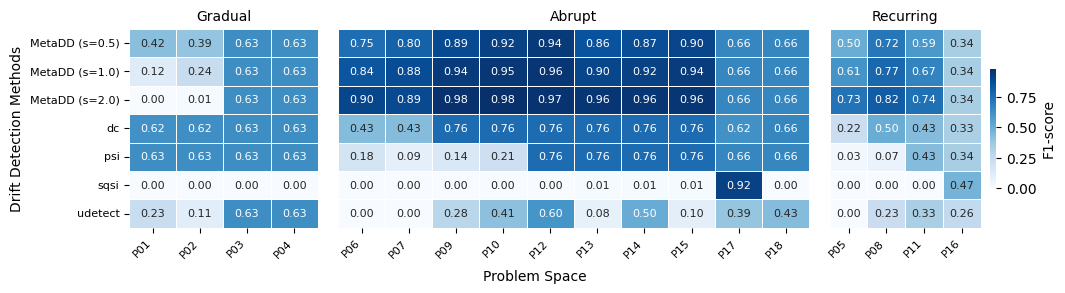

In [30]:
svc_df = get_performances("SVC")
svc_df = prepare_results(svc_df)
plot_heatmap_grouped(svc_df, groups, 'f1-score', 'F1-score')

In [31]:
clean_svc_df = clean_dataframe(svc_df).T
friedman_test_2(clean_svc_df, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 18
  k (methods) : 7
  χ²_F        : 55.2046  (p = 0.0000)
  F_F         : 17.7757  (p = 0.0000)  [df1=6, df2=102]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

psi               4.14
udetect           5.58
sqsi              6.22
dc                4.03
MetaDD (s=0.5)    3.11
MetaDD (s=1.0)    2.67
MetaDD (s=2.0)    2.25
dtype: float64

Critical Distance (CD): 2.12

                meanrank    median       mad  ci_lower  ci_upper effect_size  \
sqsi            6.222222  0.000000       0.0       0.0  0.919192         NaN   
udetect         5.583333  0.269904  0.163396       0.0  0.629096    -1.57564   
psi             4.138889  0.629096  0.127568  0.067416  0.756664   -4.703981   
dc              4.027778  0.626390  0.130274  0.329412  0.756664   -4.586469   
MetaDD (s=0.5)  3.111111  0.688136  0.176804  0.392252  0.943194   -3.712551   
MetaDD (s=1.0)  2.666667  0.721212  0.168132  0.241042  0.964912   -4.091695   
MetaDD (s=2.0)  2.250000  0.778933  0.164233  0.008299  0.984305    -4.52407   

               magnitude effect_size_above magnitude_above  
sqsi               large               0.0      negligible  
udetect            large      

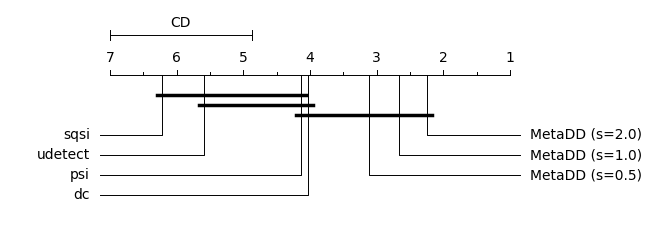

In [32]:
ranks = get_ranking(clean_svc_df)
print(ranks.round(2))
print('')
cd = get_critical_distance(clean_svc_df, ranks, verbose=True)
print('')
plot_cd_diagram(clean_svc_df)

## BaseModel: LogisticRegression

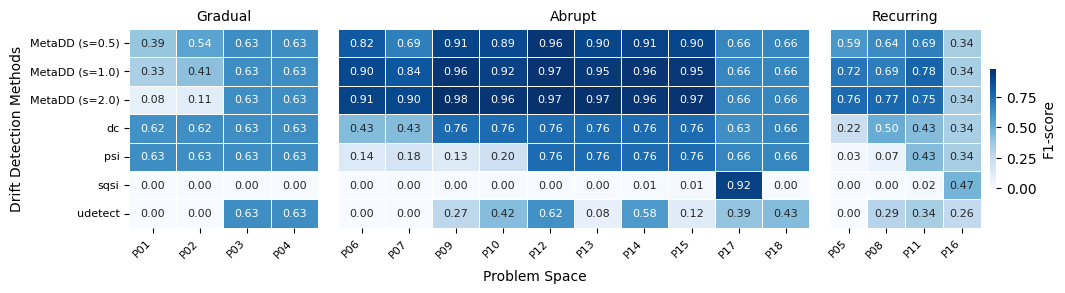

In [33]:
lr_df = get_performances("LogisticRegression")
lr_df = prepare_results(lr_df)
plot_heatmap_grouped(lr_df, groups, 'f1-score', 'F1-score')

In [34]:
clean_lr_df = clean_dataframe(lr_df).T
friedman_test_2(clean_lr_df, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 18
  k (methods) : 7
  χ²_F        : 55.4609  (p = 0.0000)
  F_F         : 17.9454  (p = 0.0000)  [df1=6, df2=102]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

psi               4.14
udetect           5.81
sqsi              6.19
dc                4.03
MetaDD (s=0.5)    3.11
MetaDD (s=1.0)    2.56
MetaDD (s=2.0)    2.17
dtype: float64

Critical Distance (CD): 2.12

                meanrank    median       mad  ci_lower  ci_upper effect_size  \
sqsi            6.194444  0.000000       0.0       0.0  0.919192         NaN   
udetect         5.805556  0.284744  0.244318       0.0  0.629096   -1.111704   
psi             4.138889  0.629096  0.127568  0.067039  0.756664   -4.703981   
dc              4.027778  0.629096  0.127568  0.336449  0.756664   -4.703981   
MetaDD (s=0.5)  3.111111  0.672261  0.141007   0.38814  0.961749   -4.547662   
MetaDD (s=1.0)  2.555556  0.751465  0.156004  0.340326  0.969163   -4.594765   
MetaDD (s=2.0)  2.166667  0.767109  0.169459  0.110236   0.98434   -4.318008   

               magnitude effect_size_above magnitude_above  
sqsi               large               0.0      negligible  
udetect            large      

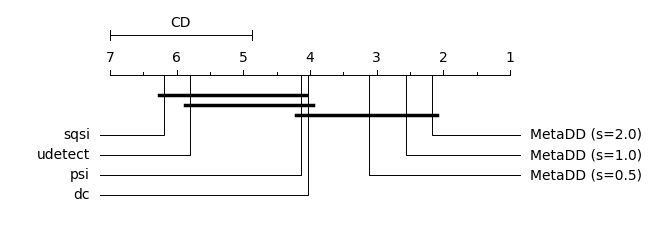

In [78]:
ranks = get_ranking(clean_lr_df)
print(ranks.round(2))
print('')
cd = get_critical_distance(clean_lr_df, ranks, verbose=True)
print('')
plot_cd_diagram(clean_lr_df)

## BaseModel: DecisionTreeClassifier

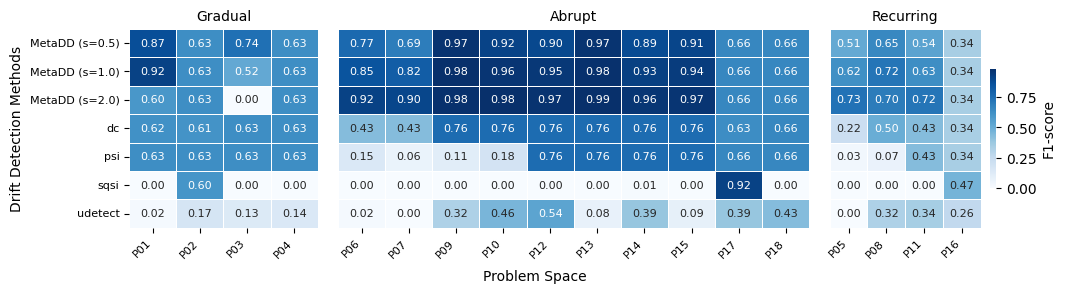

In [36]:
dt_df = get_performances("DecisionTreeClassifier")
dt_df = prepare_results(dt_df)
plot_heatmap_grouped(dt_df, groups, 'f1-score', 'F1-score')

In [37]:
clean_dt_df = clean_dataframe(dt_df).T
friedman_test_2(clean_dt_df, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 18
  k (methods) : 7
  χ²_F        : 52.3029  (p = 0.0000)
  F_F         : 15.9640  (p = 0.0000)  [df1=6, df2=102]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

psi               4.25
udetect           6.00
sqsi              6.19
dc                4.22
MetaDD (s=0.5)    2.86
MetaDD (s=1.0)    2.25
MetaDD (s=2.0)    2.22
dtype: float64

Critical Distance (CD): 2.12

                meanrank    median       mad  ci_lower  ci_upper effect_size  \
sqsi            6.194444  0.000000       0.0       0.0  0.919192         NaN   
udetect         6.000000  0.215239  0.155592       0.0  0.537967   -1.319549   
psi             4.250000  0.629096  0.127568     0.064  0.756664   -4.703981   
dc              4.222222  0.629096  0.127568  0.336449  0.756664   -4.703981   
MetaDD (s=0.5)  2.861111  0.719101  0.159663  0.513514  0.974529   -4.296127   
MetaDD (s=1.0)  2.250000  0.769408  0.148195   0.51831   0.98427   -4.952376   
MetaDD (s=2.0)  2.222222  0.727839  0.182865  0.340326  0.986547   -3.796602   

               magnitude effect_size_above magnitude_above  
sqsi               large               0.0      negligible  
udetect            large      

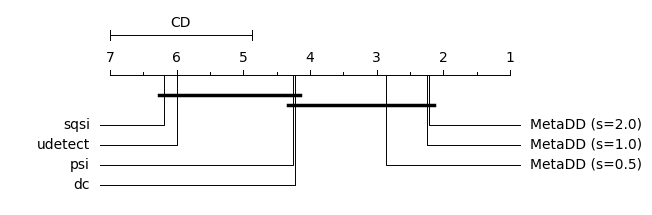

In [79]:
ranks = get_ranking(clean_dt_df)
print(ranks.round(2))
print('')
cd = get_critical_distance(clean_dt_df, ranks, verbose=True)
print('')
plot_cd_diagram(clean_dt_df)

## BaseModel: RandomForestClassifier

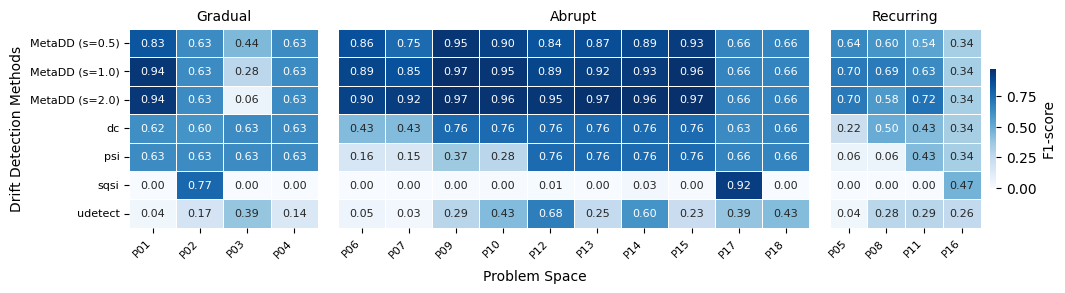

In [39]:
rf_df = get_performances("RandomForestClassifier")
rf_df = prepare_results(rf_df)
plot_heatmap_grouped(rf_df, groups, 'f1-score', 'F1-score')

In [40]:
clean_rf_df = clean_dataframe(rf_df).T
friedman_test_2(clean_rf_df, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 18
  k (methods) : 7
  χ²_F        : 59.9825  (p = 0.0000)
  F_F         : 21.2360  (p = 0.0000)  [df1=6, df2=102]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

psi               4.25
udetect           5.94
sqsi              6.00
dc                4.28
MetaDD (s=0.5)    3.03
MetaDD (s=1.0)    2.36
MetaDD (s=2.0)    2.14
dtype: float64

Critical Distance (CD): 2.12

                meanrank    median       mad  ci_lower  ci_upper effect_size  \
sqsi            6.000000  0.000000       0.0       0.0  0.919192         NaN   
udetect         5.944444  0.271544   0.12201  0.039216  0.682234   -2.122935   
dc              4.277778  0.629096  0.127568  0.336449  0.756664   -4.703981   
psi             4.250000  0.629096  0.127568  0.058537  0.756664   -4.703981   
MetaDD (s=0.5)  3.027778  0.706073  0.142175  0.439425  0.949299   -4.737141   
MetaDD (s=1.0)  2.361111  0.775351  0.143785  0.340326  0.974416   -5.143687   
MetaDD (s=2.0)  2.138889  0.813862  0.153673  0.340326  0.973349   -5.051768   

               magnitude effect_size_above magnitude_above  
sqsi               large               0.0      negligible  
udetect            large      

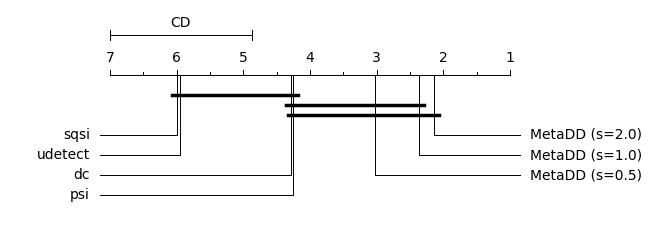

In [77]:
ranks = get_ranking(clean_rf_df)
print(ranks.round(2))
print('')
cd = get_critical_distance(clean_rf_df, ranks, verbose=True)
print('')
plot_cd_diagram(clean_rf_df)

## Other tests and ...

In [45]:
final_performances_df.loc[
            (final_performances_df["dataset"] == 'abrupt_stagger_balanced') &
            (final_performances_df["alert_col"] == 'psi_drift_flag'),
            "f1-score"
            ].iloc[0].item()

0.6586248492159228

In [46]:
friedman_test_cols

['psi_drift_flag',
 'u_detect_drift_flag',
 'sqsi_drift_flag',
 'dc_drift_flag',
 'mtl_alert_kappa_s=0.5',
 'mtl_alert_kappa_s=1',
 'mtl_alert_kappa_s=2']

In [47]:
# rows = datasets, columns = algorithms
data_dic = {}
for row_value in friedman_test_rows:
    #print(row)
    row = []
    for col_value in friedman_test_cols:
        filtered = final_performances_df.loc[
            (final_performances_df["dataset"] == row_value) &
            (final_performances_df["alert_col"] == col_value),
            "f1-score"
            ].iloc[0].item()
        row.append(filtered)

    data_dic[row_value] = row

In [48]:
# Show as text
for dataset, score in data_dic.items():
    formatted_list = [float(f"{num:.4f}") for num in score]
    print(f"{dataset} = {formatted_list}")

gradual_agrawal_balanced_with_noise = [0.6291, 0.2332, 0.0, 0.6182, 0.4205, 0.1164, 0.0]
gradual_agrawal_balanced = [0.6291, 0.1103, 0.0, 0.6237, 0.3923, 0.241, 0.0083]
gradual_agrawal_unbalanced_with_noise = [0.6291, 0.6291, 0.0, 0.6291, 0.6291, 0.6291, 0.6291]
gradual_agrawal_unbalanced = [0.6291, 0.6291, 0.0, 0.6291, 0.6291, 0.6291, 0.6291]
abrupt_recurring_mixed_balanced = [0.029, 0.0, 0.0, 0.221, 0.4966, 0.605, 0.7273]
abrupt_mixed_balanced = [0.1769, 0.0, 0.0, 0.4315, 0.7483, 0.8392, 0.903]
abrupt_mixed_unbalanced = [0.0889, 0.0, 0.0, 0.4306, 0.7955, 0.877, 0.8917]
abrupt_recurring_sea = [0.0674, 0.2269, 0.0, 0.4973, 0.7176, 0.7733, 0.8168]
abrupt_sea_noise = [0.1449, 0.2813, 0.0, 0.7567, 0.888, 0.9382, 0.9767]
abrupt_sea = [0.2121, 0.4149, 0.0, 0.7556, 0.9195, 0.9544, 0.9843]
abrupt_recurring_sine_balanced = [0.4306, 0.3321, 0.0, 0.4306, 0.5879, 0.6691, 0.7411]
abrupt_sine_unbalanced = [0.7567, 0.6014, 0.0, 0.7567, 0.9432, 0.9649, 0.9692]
abrupt_sine_unbalanced_noise = [0.7567, 

In [49]:
df = final_performances_df
df = df[df["dataset"] != "gradual_friedman"]
df = pd.DataFrame.from_dict(data_dic, orient='index', columns=['psi', 'udetect', 'sqsi', 'dc', 'MetaDD (s=0.5)', 'MetaDD (s=1.0)', 'MetaDD (s=2.0)'])
df.index = df.index.map(dataset_rename)  # renomeia os datasets direto no índice

# Sort rows by index in ascending order (default)
df_sorted = df.sort_index()
df = df_sorted.T                        # transpõe: métodos nas linhas, datasets nas colunas
df

,P01,P02,P03,P04,P05,P06,P07,P08,P09,P10,P11,P12,P13,P14,P15,P16,P17,P18
psi,0.629096,0.629096,0.629096,0.629096,0.028986,0.176871,0.088889,0.067416,0.144869,0.212121,0.430584,0.756664,0.756664,0.756664,0.756664,0.340326,0.658625,0.658625
udetect,0.233236,0.110345,0.629096,0.629096,0.000000,0.000000,0.000000,0.226891,0.281304,0.414861,0.332130,0.601432,0.079665,0.500669,0.102669,0.258503,0.388350,0.428875
sqsi,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.009029,0.009029,0.009050,0.467153,0.919192,0.000000
dc,0.618230,0.623684,0.629096,0.629096,0.220994,0.431452,0.430584,0.497336,0.756664,0.755594,0.430584,0.756664,0.756664,0.756664,0.756664,0.329412,0.615578,0.658625
MetaDD (s=0.5),0.420485,0.392252,0.629096,0.629096,0.496644,0.748252,0.795539,0.717647,0.887992,0.919540,0.587879,0.943194,0.856865,0.873016,0.904419,0.340326,0.658625,0.658625
MetaDD (s=1.0),0.116364,0.241042,0.629096,0.629096,0.605042,0.839216,0.877049,0.773333,0.938166,0.954447,0.669091,0.964912,0.901639,0.917623,0.936170,0.340326,0.658625,0.658625
MetaDD (s=2.0),0.000000,0.008299,0.629096,0.629096,0.727273,0.902954,0.891667,0.816794,0.976693,0.984305,0.741071,0.969163,0.957563,0.959651,0.964912,0.340326,0.658625,0.658625


In [50]:
df_gradual = df[['P01','P02','P03','P04']]
df_gradual

,P01,P02,P03,P04
psi,0.629096,0.629096,0.629096,0.629096
udetect,0.233236,0.110345,0.629096,0.629096
sqsi,0.000000,0.000000,0.000000,0.000000
dc,0.618230,0.623684,0.629096,0.629096
MetaDD (s=0.5),0.420485,0.392252,0.629096,0.629096
MetaDD (s=1.0),0.116364,0.241042,0.629096,0.629096
MetaDD (s=2.0),0.000000,0.008299,0.629096,0.629096


In [51]:
friedman_test_2(df_gradual.T, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 7
  k (methods) : 4
  χ²_F        : 17.8431  (p = 0.0066)
  F_F         : 33.9130  (p = 0.0000)  [df1=3, df2=18]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

In [52]:
df_recurring = df[['P05','P08','P11','P16']]
df_recurring.T

,psi,udetect,sqsi,dc,MetaDD (s=0.5),MetaDD (s=1.0),MetaDD (s=2.0)
P05,0.028986,0.000000,0.000000,0.220994,0.496644,0.605042,0.727273
P08,0.067416,0.226891,0.000000,0.497336,0.717647,0.773333,0.816794
P11,0.430584,0.332130,0.000000,0.430584,0.587879,0.669091,0.741071
P16,0.340326,0.258503,0.467153,0.329412,0.340326,0.340326,0.340326


In [53]:
friedman_test_2(df_recurring.T, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 7
  k (methods) : 4
  χ²_F        : 14.8585  (p = 0.0214)
  F_F         : 14.5161  (p = 0.0000)  [df1=3, df2=18]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

In [54]:
df_abrupt = df[["P06", "P07", "P09", "P10", "P12", "P13", "P14", "P15", "P17", "P18"]]
df_abrupt.T

,psi,udetect,sqsi,dc,MetaDD (s=0.5),MetaDD (s=1.0),MetaDD (s=2.0)
P06,0.176871,0.000000,0.000000,0.431452,0.748252,0.839216,0.902954
P07,0.088889,0.000000,0.000000,0.430584,0.795539,0.877049,0.891667
P09,0.144869,0.281304,0.000000,0.756664,0.887992,0.938166,0.976693
P10,0.212121,0.414861,0.000000,0.755594,0.919540,0.954447,0.984305
P12,0.756664,0.601432,0.000000,0.756664,0.943194,0.964912,0.969163
P13,0.756664,0.079665,0.009029,0.756664,0.856865,0.901639,0.957563
P14,0.756664,0.500669,0.009029,0.756664,0.873016,0.917623,0.959651
P15,0.756664,0.102669,0.009050,0.756664,0.904419,0.936170,0.964912
P17,0.658625,0.388350,0.919192,0.615578,0.658625,0.658625,0.658625
P18,0.658625,0.428875,0.000000,0.658625,0.658625,0.658625,0.658625


In [55]:
friedman_test_2(df_abrupt.T, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 7
  k (methods) : 10
  χ²_F        : 46.4198  (p = 0.0000)
  F_F         : 16.7983  (p = 0.0000)  [df1=9, df2=54]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

In [56]:
df_drifts = pd.DataFrame({
    group_name: df[cols].mean(axis=1)
    for group_name, cols in groups.items()
})
#df_drifts = df_drifts.drop(index='omvpth')
df_drifts

,Gradual,Abrupt,Recurring
psi,0.629096,0.496665,0.216828
udetect,0.400443,0.279782,0.204381
sqsi,0.000000,0.094630,0.116788
dc,0.625026,0.667515,0.369581
MetaDD (s=0.5),0.517732,0.824607,0.535624
MetaDD (s=1.0),0.403899,0.864647,0.596948
MetaDD (s=2.0),0.316623,0.892416,0.656366


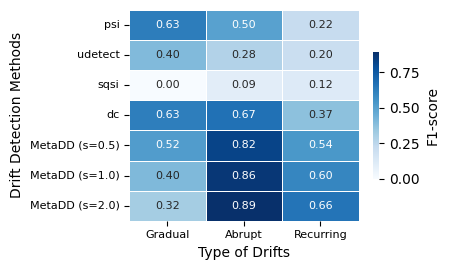

In [57]:
heatmap(df_drifts, 1.5, .4)

In [58]:
df_drifts.T

,psi,udetect,sqsi,dc,MetaDD (s=0.5),MetaDD (s=1.0),MetaDD (s=2.0)
Gradual,0.629096,0.400443,0.000000,0.625026,0.517732,0.403899,0.316623
Abrupt,0.496665,0.279782,0.094630,0.667515,0.824607,0.864647,0.892416
Recurring,0.216828,0.204381,0.116788,0.369581,0.535624,0.596948,0.656366


In [59]:
friedman_test_2(df_drifts.T, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 7
  k (methods) : 3
  χ²_F        : 10.8571  (p = 0.0929)
  F_F         : 20.7273  (p = 0.0001)  [df1=2, df2=12]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

In [60]:
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# 1. Primeiro testa H0 global com Friedman
stat, p_value = friedmanchisquare(*[df_drifts.loc[row] for row in df_drifts.index])
print(f"Friedman p-value: {p_value:.4f}")

# 2. Só se H0 for rejeitada, aplica o post-hoc
if p_value < 0.05:
    print("✅ H0 rejeitada — aplicando post-hoc de Nemenyi...\n")
    posthoc = sp.posthoc_nemenyi_friedman(df_gradual.T)
    print(posthoc)
else:
    print("❌ H0 não rejeitada — post-hoc não aplicável.")

Friedman p-value: 0.0929
❌ H0 não rejeitada — post-hoc não aplicável.


In [61]:
import numpy as np
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

data = np.array(list(data_dic.values()))

# Friedman test
stat, p = friedmanchisquare(*data.T)
print(f"Friedman stat={stat:.4f}, p={p:.4f}")

# Nemenyi post-hoc
nemenyi = sp.posthoc_nemenyi_friedman(data)
print(nemenyi)

Friedman stat=57.2733, p=0.0000
          0         1             2         3         4         5  \
0  1.000000  0.410739  5.848692e-02  0.999999  0.787163  0.386395   
1  0.410739  1.000000  9.745682e-01  0.317421  0.010684  0.001005   
2  0.058487  0.974568  1.000000e+00  0.037344  0.000313  0.000016   
3  0.999999  0.317421  3.734427e-02  1.000000  0.864443  0.486791   
4  0.787163  0.010684  3.129422e-04  0.864443  1.000000  0.996296   
5  0.386395  0.001005  1.634468e-05  0.486791  0.996296  1.000000   
6  0.118953  0.000075  7.230631e-07  0.170683  0.896011  0.997411   

              6  
0  1.189526e-01  
1  7.511347e-05  
2  7.230631e-07  
3  1.706826e-01  
4  8.960114e-01  
5  9.974111e-01  
6  1.000000e+00  


In [62]:
import numpy as np
from scipy.stats import studentized_range

def compute_cd(k, N, alpha=0.05):
    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    return q_alpha * np.sqrt(k * (k + 1) / (6 * N))

ALPHA = 0.05
cd = compute_cd(k=data.shape[1], N=data.shape[0], alpha=ALPHA)
print("Critical distance (CD):", cd)

Critical distance (CD): 2.1230330588372373


In [63]:
df = col_filter(final_performances_df)
df["dataset"] = df["dataset"].replace(dataset_rename)
df["alert_col"] = df["alert_col"].replace(alert_col_rename)

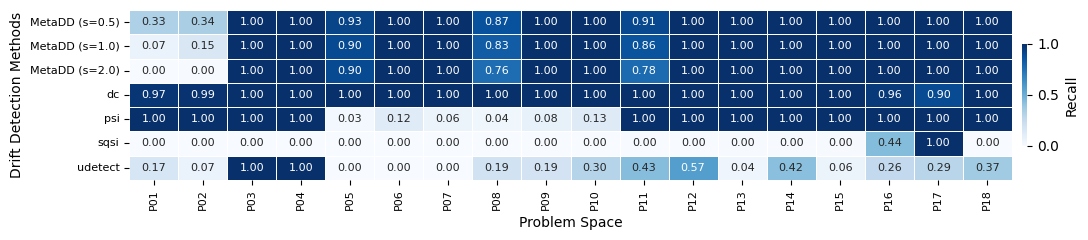

In [64]:
plot_heatmap(df, 'recall', 'Recall')

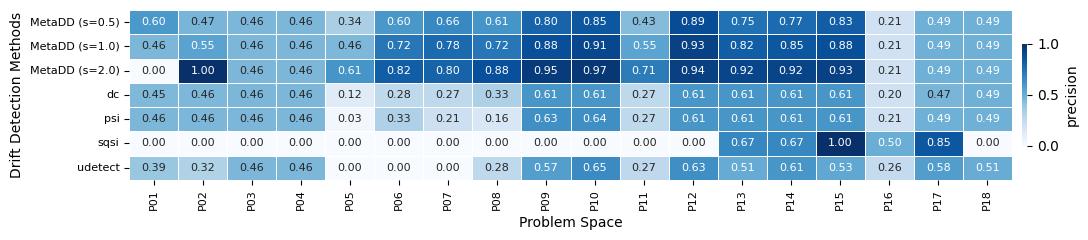

In [65]:
plot_heatmap(df, 'precision')

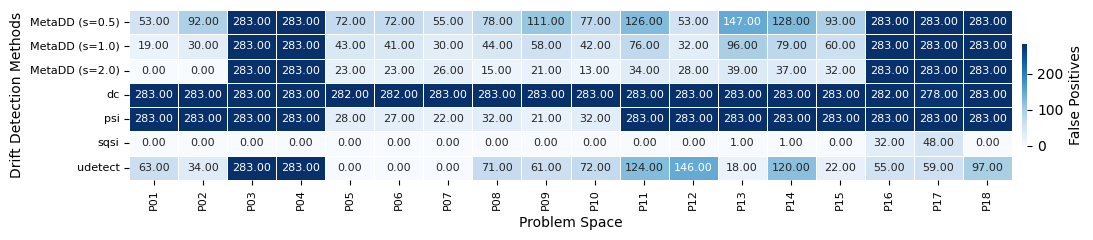

In [66]:
plot_heatmap(df, 'False Positives')

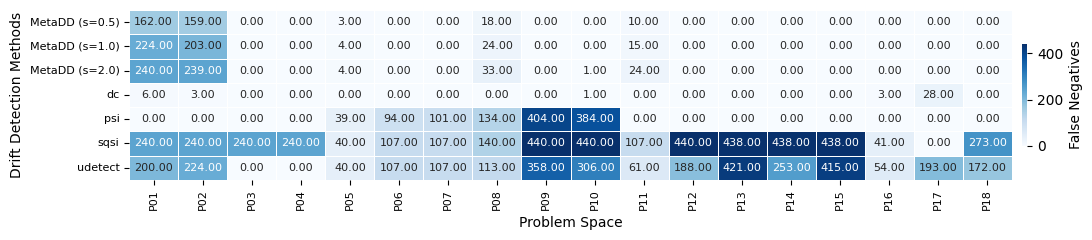

In [67]:
plot_heatmap(df, 'False Negatives')

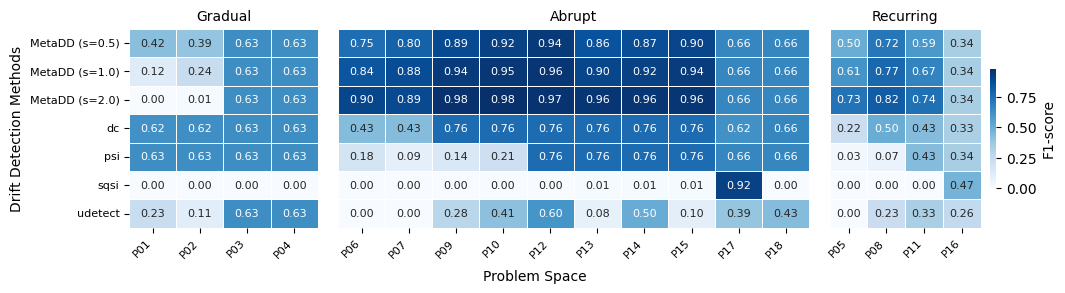

In [68]:
plot_heatmap_grouped(df, groups, 'f1-score', 'F1-score')

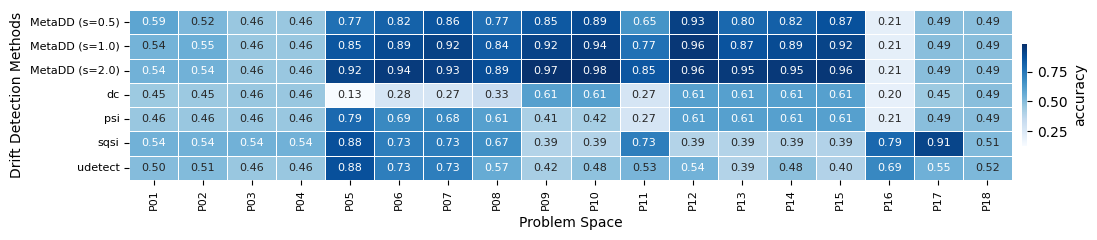

In [69]:
plot_heatmap(df, 'accuracy')

# Friedman test

In [70]:
def evaluate_classifiers_friedman(data: pd.DataFrame, metric: str):
    num_datasets, num_classifiers = data.shape

    # Compute ranks for each dataset
    ranks = []
    for i in range(num_datasets):
        ranks.append(rankdata(-np.array(data.iloc[i])))

    # Calculate average ranks
    avg_ranks = np.mean(ranks, axis=0)

    # Perform the Friedman test
    chi2, _ = friedmanchisquare(*ranks)
    df_between = num_classifiers - 1
    df_within = (num_classifiers - 1) * (num_datasets - 1)
    f_value = (num_datasets - 1) * chi2 / df_within
    p_value = 1 - f.cdf(f_value, df_between, df_within)

    # Create list of dictionaries with classifier ranks
    return [{
            "Classifier": classifier,
            "Ranking Position": pos + 1,
            "Average Rank": rank,
            "Metric": metric,
            "chi2": chi2,
            "p_value": p_value,
        } for pos, (classifier, rank) in enumerate(sorted(zip(data.columns, avg_ranks), key=lambda x: x[1]))
    ]

def evaluate_all_metrics(final_performances_df: pd.DataFrame):
    metrics = ["precision", "recall", "f1-score"]
    cols_to_drop = ["target_alert"] #, "mtl_alert_kappa_s=1.5", "mtl_alert_kappa_s=1", "mtl_alert_kappa_s=0.5"]
    results = []
    clf_results = final_performances_df.copy()
    clf_results = final_performances_df[final_performances_df["dataset"] != 'gradual_friedman']

    for metric in metrics:
        results_pivot = clf_results.pivot(index="dataset", values=metric, columns='alert_col').drop(cols_to_drop, axis=1)
        for col in results_pivot.columns:
            results_pivot = results_pivot.rename(columns={col: col.replace("dc_drift_flag", "domain_classifier").replace("_drift_flag", "").replace("_alert_kappa", "")})

        results = [*results, *evaluate_classifiers_friedman(results_pivot, metric)]
    return pd.DataFrame(results)

In [71]:
friedman_results = evaluate_all_metrics(final_performances_df)
friedman_results.head(10)

,Classifier,Ranking Position,Average Rank,Metric,chi2,p_value
0,mtl_s=2,1,2.775,precision,13.162629,0.116412
1,mtl_s=1.5,2,2.975,precision,13.162629,0.116412
2,mtl_s=1,3,3.725,precision,13.162629,0.116412
3,mtl_s=0.5,4,4.175,precision,13.162629,0.116412
4,psi,5,5.450,precision,13.162629,0.116412
5,u_detect,6,5.650,precision,13.162629,0.116412
6,domain_classifier,7,5.850,precision,13.162629,0.116412
7,sqsi,8,6.625,precision,13.162629,0.116412
8,omv_pth,9,7.775,precision,13.162629,0.116412
9,mtl_s=0.5,1,3.300,recall,10.913307,0.216569


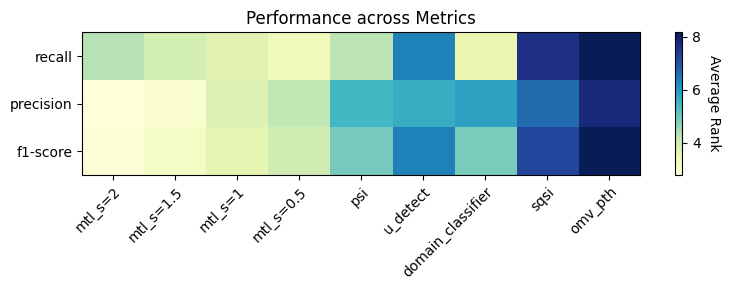

In [72]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ranking_heatmap(results: list):
    # Prepare data
    metrics = list(set(result["Metric"] for result in results))
    classifiers = list(set(result["Classifier"] for result in results))
    num_classifiers = len(classifiers)
    num_metrics = len(metrics)

    # Sort classifiers based on precision values
    sorted_classifiers = sorted(classifiers, key=lambda c: next((result["Average Rank"] for result in results if result["Classifier"] == c and result["Metric"] == "precision"), 0))

    # Create a data array for heatmap
    data = np.zeros((num_metrics, num_classifiers))
    for result in results:
        classifier_idx = sorted_classifiers.index(result["Classifier"])
        metric_idx = metrics.index(result["Metric"])
        data[metric_idx, classifier_idx] = result["Average Rank"]

    # Create heatmap
    fig, ax = plt.subplots(figsize=(8, 3))
    heatmap = ax.imshow(data, cmap='YlGnBu', aspect='auto')

    # Set x-axis and y-axis labels
    ax.set_xticks(np.arange(num_classifiers))
    ax.set_yticks(np.arange(num_metrics))
    ax.set_xticklabels(sorted_classifiers, rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(metrics)

    # Add colorbar
    cbar = ax.figure.colorbar(heatmap, ax=ax)
    cbar.ax.set_ylabel('Average Rank', rotation=-90, va="bottom")

    # Set title and adjust layout
    ax.set_title("Performance across Metrics")
    plt.tight_layout()

    # Display the heatmap
    plt.show()

plot_ranking_heatmap(friedman_results.to_dict(orient='records'))

# Carregando modelo salvo no PICKLES

In [73]:
import pickle

# Open the file in binary mode and load the data
with open('../models/basemodel: RandomForestClassifier - dataset: abrupt_sea.csv - with_drift_metrics - metric: f1-score.pickle', 'rb') as file:
    my_model = pickle.load(file)

print(my_model)

LGBMRegressor(max_depth=8, n_jobs=-1, num_leaves=21, random_state=2022,
              verbose=-1)


In [74]:
type(my_model)

lightgbm.sklearn.LGBMRegressor

                   feature  importance
2                    psi_2          12
54   predict_proba_0_gmean          12
50                 2_gmean          11
27     predict_proba_0_max          10
47                 1_hmean           8
91          kmeans_inertia           8
5              psi_predict           8
21                   2_std           5
19                   1_max           4
20                  2_mean           3
1                    psi_1           3
12                  0_mean           3
43                 0_hmean           3
61  predict_proba_1_median           2
15                   0_max           2
30     predict_proba_1_min           2
46                 1_gmean           1
42                 0_gmean           1
17                   1_std           1
98              last_kappa           1


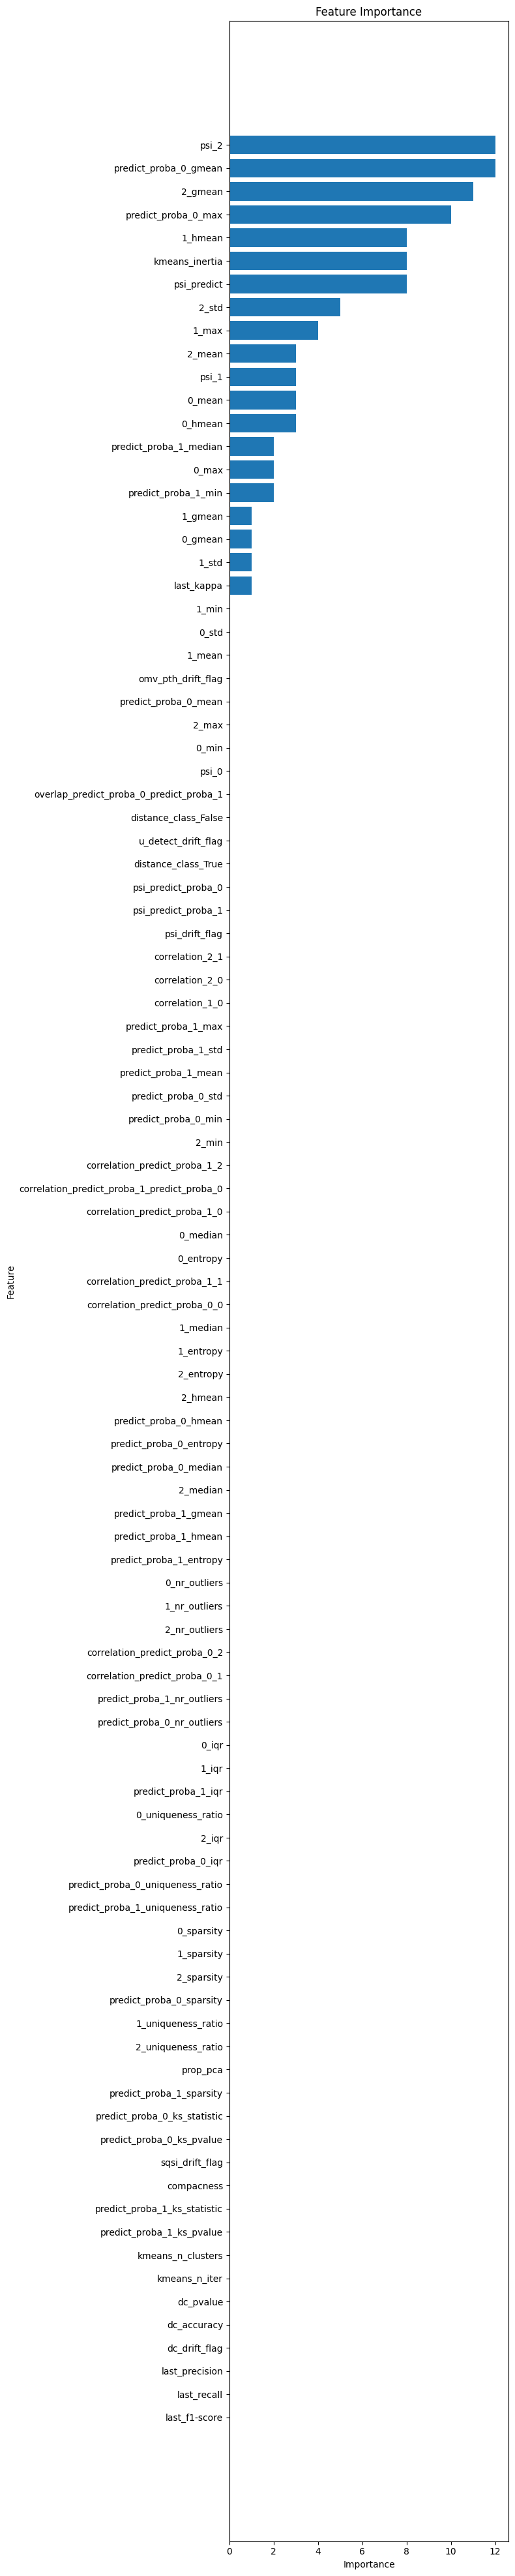

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# Obtém as feature importances
feature_importance = pd.DataFrame({
    'feature':   my_model.feature_name_,
    'importance': my_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance[feature_importance["importance"]>0])

# Plot
fig, ax = plt.subplots(figsize=(8, len(feature_importance) * 0.4))
ax.barh(feature_importance['feature'], feature_importance['importance'])
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.set_title('Feature Importance')
ax.invert_yaxis()  # mais importante no topo
plt.tight_layout()
plt.show()